# Overfitting Radar – Demo Notebook

This notebook gives a quick tour of the main outputs from the **Overfitting Radar** pipeline.

It assumes you have already run:

```bash
python -m src.run

In [140]:
### Cell 2 — Imports & paths

from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

HOME = Path.home()
PROJECT_ROOT = HOME / "cs4824" / "overfitting-radar"
assert (PROJECT_ROOT / "src").exists(),  "src/ not found under PROJECT_ROOT"
assert (PROJECT_ROOT / "data").exists(), "data/ not found under PROJECT_ROOT"

# Base directories (relative to repo root)
DATA_DIR  = PROJECT_ROOT / "data" / "processed"
CV_DIR    = DATA_DIR / "cv"
BT_DIR    = DATA_DIR / "backtests"
FI_DIR    = DATA_DIR / "feature_importance"
PLOTS_DIR = DATA_DIR / "plots"
VIS_DIR   = DATA_DIR / "visuals"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CV_DIR:", CV_DIR)
print("BT_DIR:", BT_DIR)
print("VIS_DIR:", VIS_DIR)

DATA_DIR, CV_DIR, BT_DIR, FI_DIR, PLOTS_DIR, VIS_DIR

PROJECT_ROOT: /Users/quinngardner/cs4824/overfitting-radar
CV_DIR: /Users/quinngardner/cs4824/overfitting-radar/data/processed/cv
BT_DIR: /Users/quinngardner/cs4824/overfitting-radar/data/processed/backtests
VIS_DIR: /Users/quinngardner/cs4824/overfitting-radar/data/processed/visuals


(PosixPath('/Users/quinngardner/cs4824/overfitting-radar/data/processed'),
 PosixPath('/Users/quinngardner/cs4824/overfitting-radar/data/processed/cv'),
 PosixPath('/Users/quinngardner/cs4824/overfitting-radar/data/processed/backtests'),
 PosixPath('/Users/quinngardner/cs4824/overfitting-radar/data/processed/feature_importance'),
 PosixPath('/Users/quinngardner/cs4824/overfitting-radar/data/processed/plots'),
 PosixPath('/Users/quinngardner/cs4824/overfitting-radar/data/processed/visuals'))

In [141]:
baseline_cv_path = CV_DIR / "baseline_cv_scores.csv"
baseline_cv = pd.read_csv(baseline_cv_path)
baseline_cv.head()
baseline_cv.columns.tolist()

['model',
 'alpha',
 'rmse_mean',
 'rmse_std',
 'C',
 'calibrated',
 'acc_mean',
 'auc_mean',
 'logloss_mean']

In [142]:
# Aggregate mean metrics by model over all CV splits
summary = (
    baseline_cv
    .groupby("model")[["rmse_mean", "acc_mean", "auc_mean"]]
    .mean()
    .reset_index()
    .sort_values("rmse_mean")
)

summary

,model,rmse_mean,acc_mean,auc_mean
1,Ridge,0.027643,NaN,NaN
0,LogReg,NaN,0.620578,NaN


Using Sharpe column: sharpe


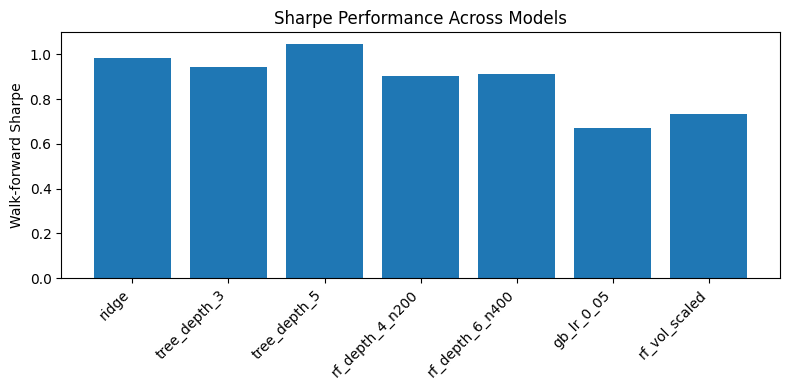

In [143]:
sharpe_col = [c for c in cmp.columns if "sharpe" in c.lower()][0]
print("Using Sharpe column:", sharpe_col)

plt.figure(figsize=(8, 4))
plt.bar(cmp["model"], cmp[sharpe_col])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Walk-forward Sharpe")
plt.title("Sharpe Performance Across Models")
plt.tight_layout()
plt.show()

In [144]:
ablation_path = BT_DIR / "feature_ablation_comparison.csv"
ablation = pd.read_csv(ablation_path)
ablation

,model,feature_set,sharpe,max_drawdown,turnover
0,ridge,core,1.003610,-0.887549,0.154598
1,rf_vol_scaled,core,0.605143,-0.281118,0.062709
2,ridge,core_plus_20,1.018651,-0.870232,0.157079
3,rf_vol_scaled,core_plus_20,0.748546,-0.175187,0.054909
4,ridge,all,0.981617,-0.870232,0.157699
5,rf_vol_scaled,all,0.687063,-0.246203,0.075316


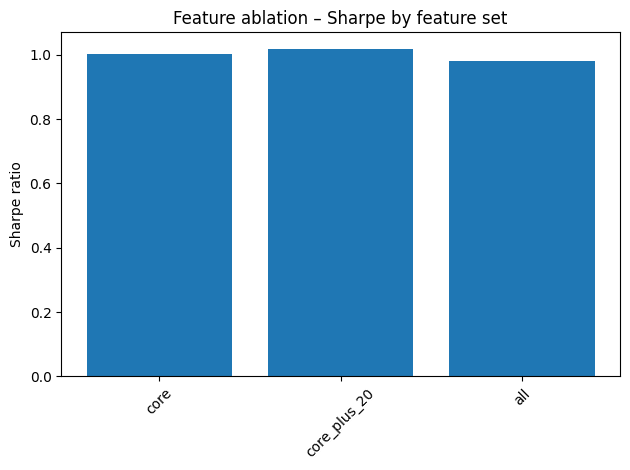

In [145]:
plt.figure()
plt.bar(ablation["feature_set"], ablation["sharpe"])
plt.xticks(rotation=45)
plt.ylabel("Sharpe ratio")
plt.title("Feature ablation – Sharpe by feature set")
plt.tight_layout()
plt.show()

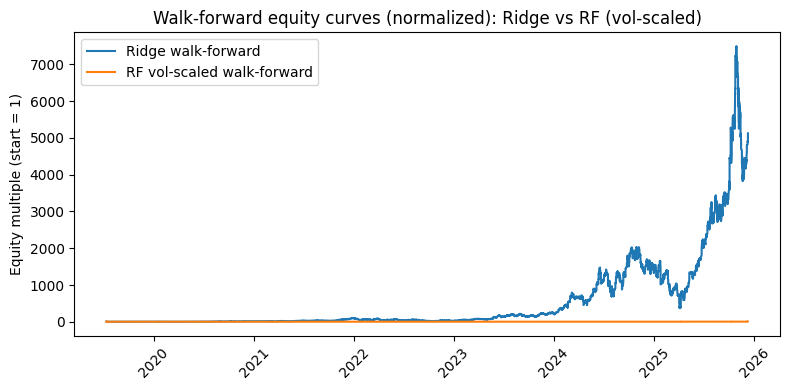

In [146]:
ridge_eq = pd.read_csv(BT_DIR / "ridge_walkforward_equity_curve.csv")
rf_vol_eq = pd.read_csv(BT_DIR / "rf_vol_scaled_walkforward_equity_curve.csv")

# Convert to datetime
ridge_eq["date"] = pd.to_datetime(ridge_eq["date"])
rf_vol_eq["date"] = pd.to_datetime(rf_vol_eq["date"])

# Normalize both curves so they start at 1
ridge_eq["equity_norm"] = ridge_eq["equity"] / ridge_eq["equity"].iloc[0]
rf_vol_eq["equity_norm"] = rf_vol_eq["equity"] / rf_vol_eq["equity"].iloc[0]

plt.figure(figsize=(8,4))
plt.plot(ridge_eq["date"], ridge_eq["equity_norm"], label="Ridge walk-forward")
plt.plot(rf_vol_eq["date"], rf_vol_eq["equity_norm"], label="RF vol-scaled walk-forward")
plt.xticks(rotation=45)
plt.ylabel("Equity multiple (start = 1)")
plt.title("Walk-forward equity curves (normalized): Ridge vs RF (vol-scaled)")
plt.legend()
plt.tight_layout()
plt.show()



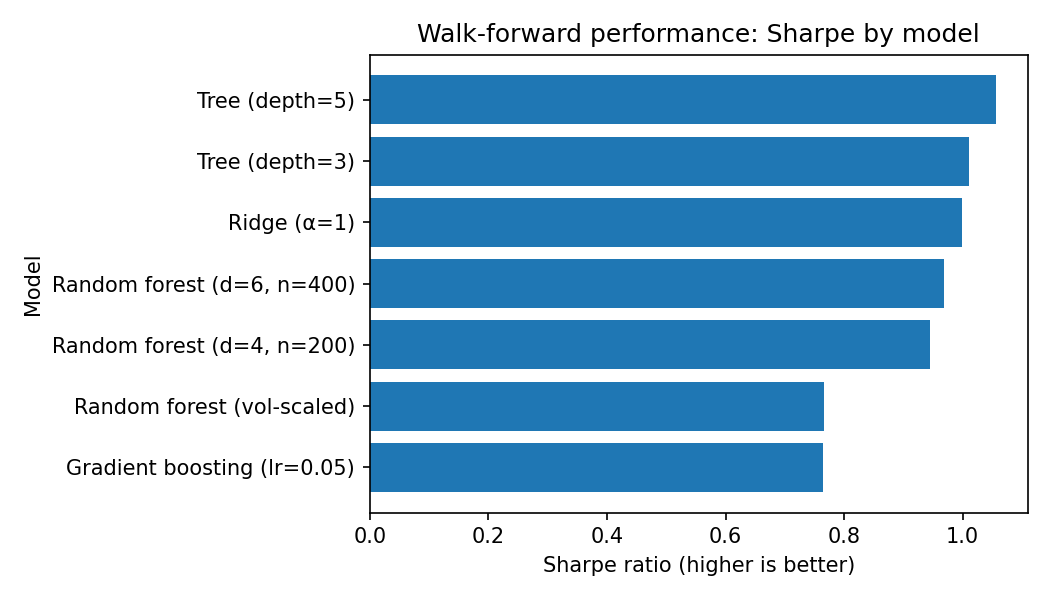

In [147]:
display(Image(filename=str(VIS_DIR / "global_sharpe_ranking.png")))

The global Sharpe ranking plot compares overall risk-adjusted performance
across different models and feature sets. Models that look great in-sample
but collapse out-of-sample will show much lower Sharpe here.

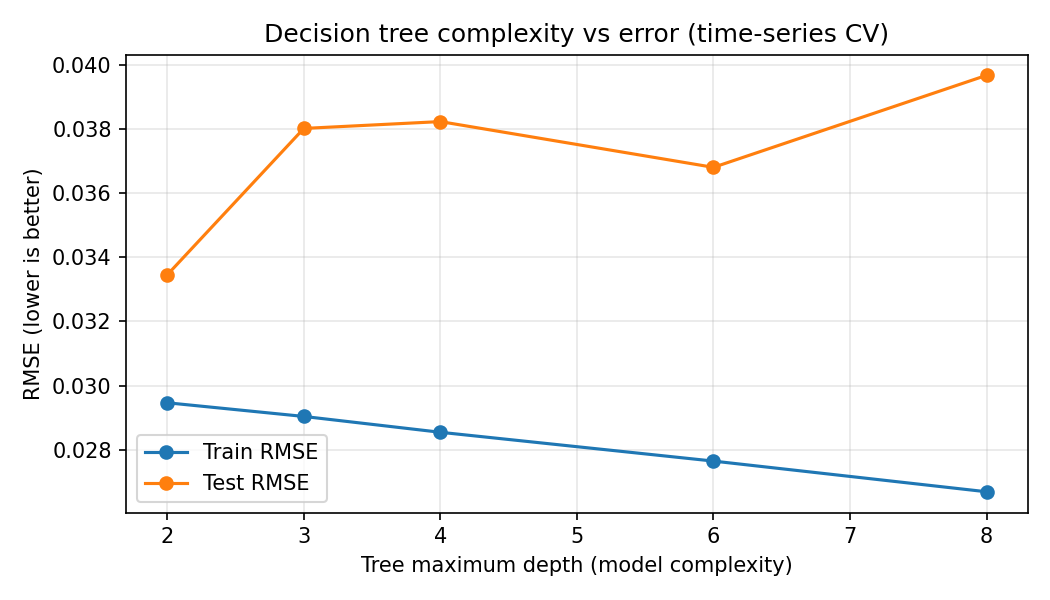

In [148]:
display(Image(filename=str(VIS_DIR / "tree_depth_overfitting.png")))

This depth curve shows classic overfitting: training error keeps decreasing
as depth grows, but test error bottoms out at a moderate depth and then
starts to worsen as the tree becomes too complex.


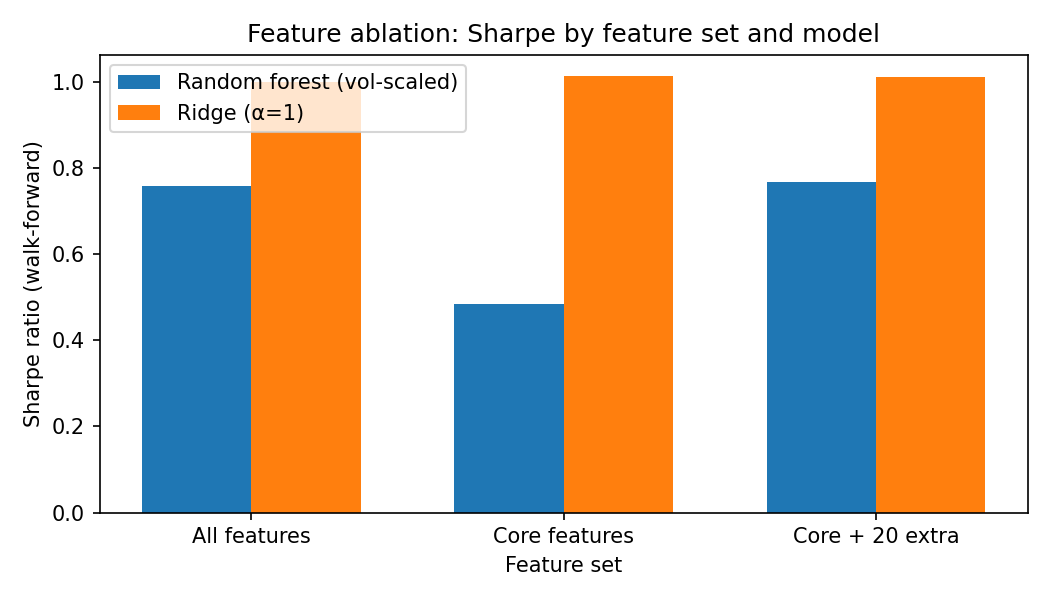

In [149]:
display(Image(filename=str(VIS_DIR / "feature_ablation_sharpe.png")))

In [150]:
ridge_fi_path = FI_DIR / "ridge_feature_importance.csv"
ridge_fi = pd.read_csv(ridge_fi_path)
ridge_fi.head()

,feature,mean_importance,std_importance
0,ret1,0.072241,0.034262
1,rv10,0.025913,0.009216
2,ret5,0.011966,0.007631
3,ret1_std_60,0.011221,0.008134
4,ret1_mean_20,0.006921,0.002818


## Takeaways

- Simple expanding time-series CV already reveals which models generalize better
  than the ridge baseline, and which ones mostly overfit.
- The tree depth curve highlights that increasing model complexity helps in-sample
  but eventually hurts test performance — the core pattern Overfitting Radar is
  designed to catch.
- Feature ablation experiments show that a compact "core" feature set
  (short-horizon returns and volatility) captures most of the signal, with only
  modest gains from adding more engineered features.
- Walk-forward backtests (equity curves and Sharpe ratios) provide a trading-level
  view of robustness, complementing the pure prediction error metrics.
